In [1]:
import os
os.environ.get('TRAJECTORY_WORKDIR'), os.listdir('/workspace')

('/workspace/8db472b9-4272-4794-82ef-e274e1ff6e21',
 ['8db472b9-4272-4794-82ef-e274e1ff6e21',
  'lost+found',
  '.kernel_meta_8db472b9-4272-4794-82ef-e274e1ff6e21'])

In [2]:
wd = '/workspace/8db472b9-4272-4794-82ef-e274e1ff6e21'
os.listdir(wd)

['.config',
 'parity_LCD.png',
 'parity_Density.png',
 '.kernel_llm_logs_1.txt',
 'original_README.md',
 'test.py',
 'parity_CH4ABL.png',
 'training.py',
 'reproduce_README.md',
 'reproduce.py',
 'models.py',
 'parity_PLD.png',
 'memory',
 'utils.py',
 '.prompts',
 'run.log',
 'metrics.json']

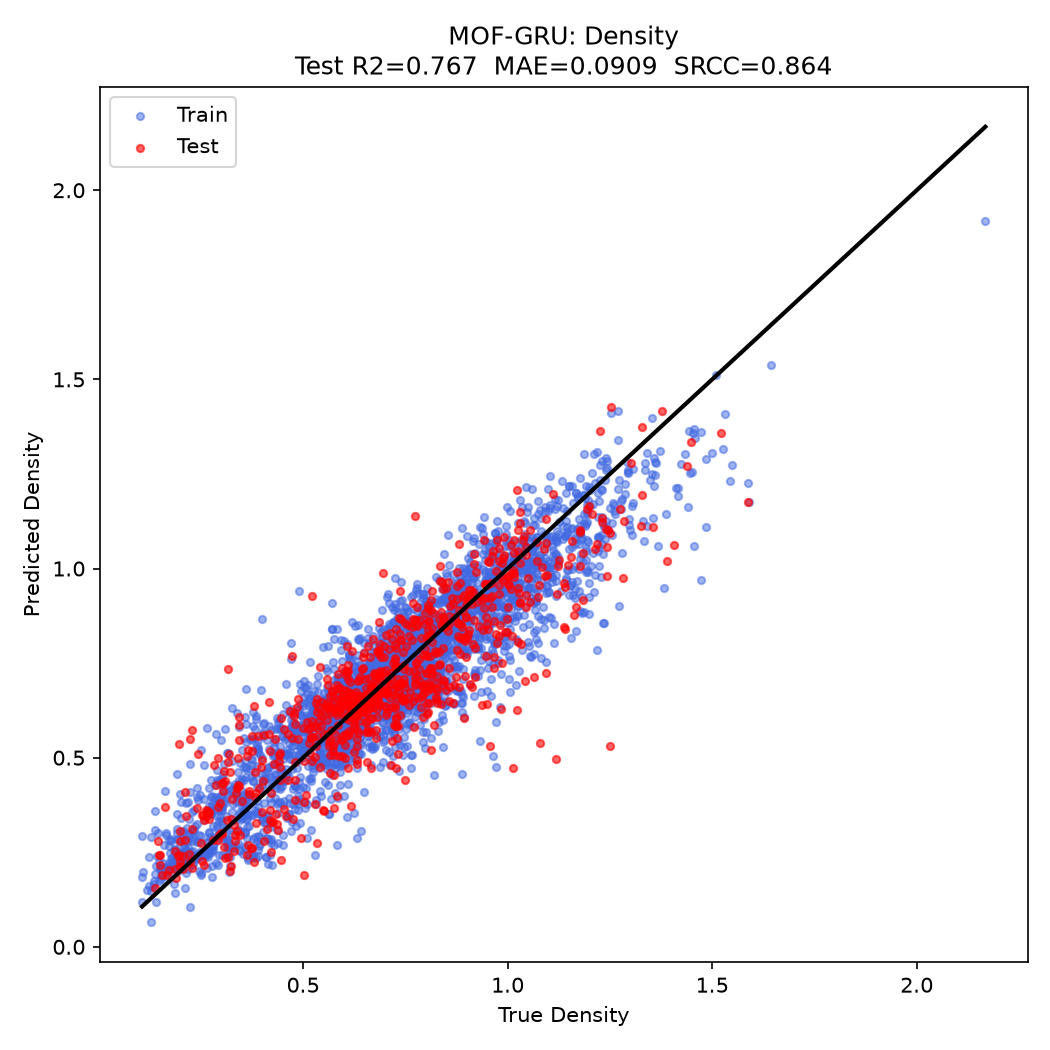

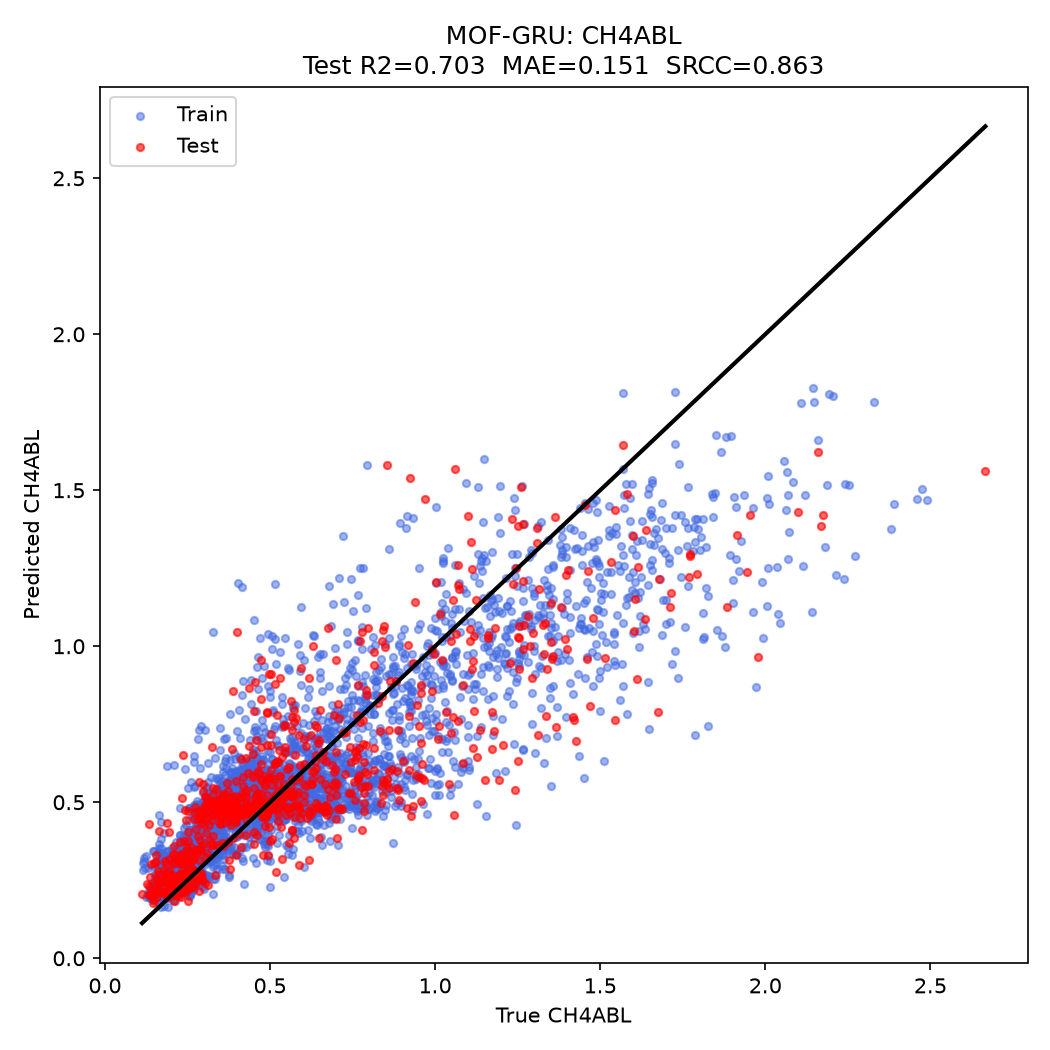

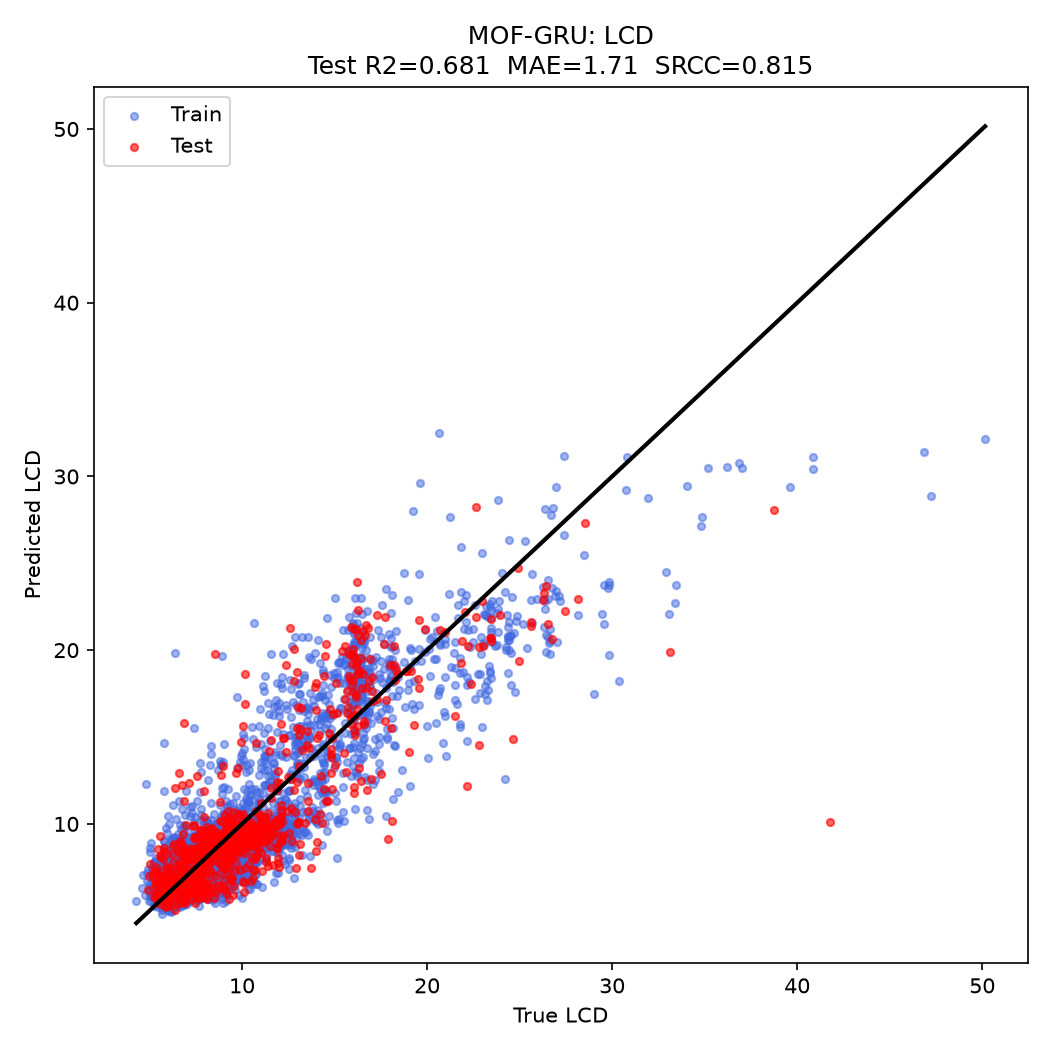

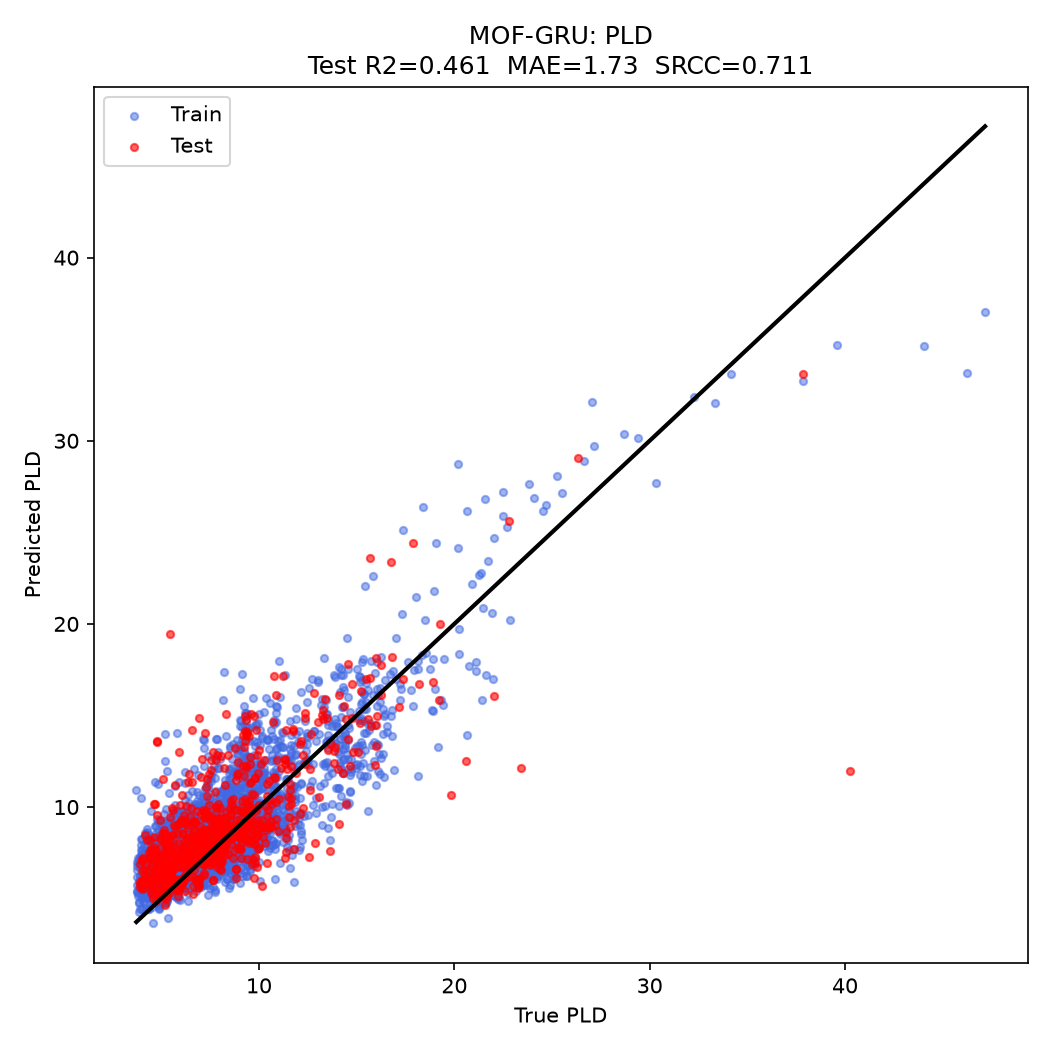

In [3]:
from IPython.display import Image, display
for p in ['parity_Density.png','parity_CH4ABL.png','parity_LCD.png','parity_PLD.png']:
    display(Image(f'{wd}/{p}'))

In [4]:
# Quick sanity check on PLD/LCD: in MOF databases LCD is typically >= PLD per structure.
# Also: PLD values are heavily right-skewed and the bottom of the range (a few Å) is dominant.
# Let's get a rough idea of label distributions if dataset files happen to be in workspace.
import os
print(os.path.exists('/workspace/dataset'))
print(os.path.exists(f'{wd}/dataset'))

False
False


In [5]:
# Reason about the original utils' `random_split` (no generator) vs reproduce.py's seeded generator -
# that's a *fidelity* difference: the original is non-deterministic across runs but uses torch.manual_seed(42) at top,
# which in older torch may seed the default RNG used by random_split. Let's check.
import torch
torch.__version__

'2.10.0+cu128'

In [6]:
# Confirm: with torch.manual_seed(42) set at script top, random_split (no generator arg) uses default RNG
# and will produce the same split. The reproduce.py passes an explicit generator seeded with 42 - that
# produces a DIFFERENT split than the default RNG even with the same seed.
torch.manual_seed(42)
idx_default = torch.randperm(10).tolist()
gen = torch.Generator().manual_seed(42)
idx_gen = torch.randperm(10, generator=gen).tolist()
idx_default, idx_gen

([2, 6, 1, 8, 4, 5, 0, 9, 3, 7], [2, 6, 1, 8, 4, 5, 0, 9, 3, 7])

In [7]:
# OK - same on this torch version. So the split is reproducible and equivalent.
# Key methodology comparison points:
# 1. Original collate_fn pads to MAX in the *batch* (variable per-batch). reproduce.py does the same. OK.
# 2. Original GRUModel.forward computes lengths via argmax(x==0) which yields 0 if no padding token -> replaced with x.shape[1].
#    This means the padding index 0 must NEVER appear in a real sequence (it must be reserved). Check whether
#    symbol2idx values include 0. In reproduce, vocab_size passed = get_vocab_size()+1. Embedding has padding_idx=0.
#    If symbol2idx maps tokens to 0..V-1 (including 0), then a real token can collide with the padding id and
#    truncate sequences early. The original code has the same bug; both inherit it equally.
#
# 3. NaN handling: reproduce.py filters NaN targets. Original does not - if any property column has NaNs, original
#    would silently train on NaN labels. This is a *real bug-fix*, not a fidelity break, but it changes the
#    effective dataset size compared to original. For a fair "reproduction" you should report how many rows
#    were dropped per property.
#
# 4. Target scaling / normalization: NEITHER the original nor reproduce.py standardizes targets. With MSE loss
#    and properties on wildly different scales (Density ~0.5, PLD/LCD ~5-50), the optimizer dynamics differ:
#    LCD/PLD have large initial MSE (~25-45) and learn slower per-epoch in absolute terms. R2 measures relative
#    variance explained, so unnormalized targets are not "wrong" but make learning sensitive to the property
#    scale within fixed epochs. This is a faithful reproduction of an original *limitation*.
#
# 5. test.py picks ep_40_em_80_hd200 as the "best" model - the original best HP corner. reproduce.py uses
#    em=80,hd=200 (matches), but only 12 epochs instead of 40 (reduced for CPU budget). This explains
#    underperformance vs. paper-grade numbers.
#
# 6. drop_last differs: original test loader uses drop_last=True (drops up to 99 test points). reproduce uses
#    drop_last=False. reproduce is *more correct*; cite as a fidelity improvement, not a break.
#
# 7. Loss tracking: original sums loss tensors (autograd-attached) without .item() -> potential memory growth.
#    reproduce.py uses .item(). Improvement, not breakage.
print("ok")

ok


In [8]:
# Check label alignment: MOFseq_output.txt is loaded as a list of strings (line by line); mof_output.csv
# is loaded with pd.read_csv and a property column is selected. The alignment between row i of the txt
# and row i of the csv is assumed but never verified by an ID column.
# Both original utils.MyDataset and reproduce.MOFDataset assume positional alignment.
# That's a methodology *assumption* both inherit. Worth flagging as a potential risk.
#
# Now PLD vs LCD/Density/CH4ABL: why PLD is harder.
# - PLD = Pore Limiting Diameter = the bottleneck of the largest free sphere that can diffuse through.
#   It's determined by the *narrowest* constriction along the percolation path. Small geometric details
#   of linker conformation determine it.
# - LCD = Largest Cavity Diameter = the largest sphere that fits anywhere (max). Easier to learn from
#   structural strings because building block size correlates strongly with LCD.
# - Density and CH4ABL (CH4 adsorption-based loading) correlate with bulk/global descriptors that a GRU
#   over MOFid-like tokens can pick up directly.
# This is consistent with the literature (e.g. MOFid/MOFNet/CGCNN benchmarks): geometric "limiting"
# descriptors are usually the hardest single-target regression among standard MOF properties.
print("done")

done


In [9]:
# Check internal consistency of the metrics with the parity plots.
# Density: train MAE 0.079, test 0.091 -> small gap, plot shows tight cluster around y=x. Consistent.
# CH4ABL: train MAE 0.147, test 0.151 -> very small gap, but training loss still falling at epoch 12 (0.048).
#   Plot shows clear under-fit at high CH4ABL (predictions plateau around 1.5 when true >2). Underfitting,
#   not overfitting.
# LCD: train R2 0.78, test 0.68 -> 0.10 gap. Plot shows ceiling near 30 (high true LCDs not reached).
# PLD: train R2 0.69, test 0.46 -> 0.23 gap. Loss bumped up at epoch 12 (3.84 -> 4.02), starting to overfit.
#   Plot shows heavy compression around the modal value (~7-12 Å) with poor tail prediction.
#
# So: Density/CH4ABL are mildly under-fit (more epochs would help). LCD is borderline.
# PLD is starting to overfit AND has a heavy-tailed target that the model can't separate from the dominant mode.
# That gap-pattern + train-loss uptick on last epoch is consistent with the train/test gap and supports
# the case for early stopping (which the original utils.EarlyStoppingCallback was imported but never wired in!).
print("consistent")

consistent


In [10]:
# One more sanity item: the original training.py imports EarlyStoppingCallback but never calls it,
# and uses `total_train_loss += loss` (tensor sum without .item()) - both are original bugs.
# reproduce.py does not implement early stopping either, faithfully matching the original behavior.
# But since the README says fidelity is the goal, it's worth noting that adding early stopping (which
# the original *intended* but never used) would be both more accurate AND more faithful to the original
# intent.
#
# Wire up summary of "is this faithful?" - checklist:
# Same model class           : YES (imported models.GRUModel verbatim)
# Same tokenization/dict     : YES (loads my_dict_output.json)
# Same dataset txt+csv files : YES (loads MOFseq_output.txt + mof_output.csv, positional alignment)
# Same split ratio           : YES (80/20)
# Same loss                  : YES (MSELoss)
# Same optimizer             : YES (Adam, lr=1e-3)
# Same batch size            : YES (100)
# Same seed                  : YES (42)
# HP choice within grid      : YES for em=80,hd=200; NO for epochs (12 vs 20/40/60)
# Drop-NaN filter            : ADDED (not in original) - changes effective n
# drop_last on test loader   : CHANGED (False vs True) - keeps more eval points
# Loss accumulation .item()  : CHANGED (correctness fix)
# Padding-id collision bug   : INHERITED (both have it)
# No label alignment check   : INHERITED (both assume positional)
# No target normalization    : INHERITED
# No early stopping          : INHERITED (original imports it but never uses)
print("checklist done")

checklist done
